In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

ModuleNotFoundError: No module named 'data_preprocess'

In [9]:
# Load preprocessed data
X_train_scaled = pd.read_csv('X_train_scaled.csv', index_col=0)
X_test_scaled = pd.read_csv('X_test_scaled.csv', index_col=0)
y_train = pd.read_csv('y_train.csv', index_col=0).squeeze()
y_test = pd.read_csv('y_test.csv', index_col=0).squeeze()

print("✓ Preprocessed data loaded")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✓ Preprocessed data loaded
X_train_scaled shape: (1433, 205)
X_test_scaled shape: (359, 205)


In [13]:
print("="*70)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*70)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"✓ Model trained on {X_train_scaled.shape[0]} samples")
print(f"  Features: {X_train_scaled.shape[1]}")
print(f"  Intercept: {model.intercept_:,.2f}")

TRAINING LINEAR REGRESSION MODEL
✓ Model trained on 1433 samples
  Features: 205
  Intercept: 112,798.26


In [11]:
#Prediction
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [14]:
# Evaluation 
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"\nTraining Set:")
print(f"  RMSE: {train_rmse:,.2f}")
print(f"  MAE:  {train_mae:,.2f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTesting Set:")
print(f"  RMSE: {test_rmse:,.2f}")
print(f"  MAE:  {test_mae:,.2f}")
print(f"  R²:   {test_r2:.4f}")


MODEL PERFORMANCE

Training Set:
  RMSE: 18,493.93
  MAE:  13,263.28
  R²:   0.8730

Testing Set:
  RMSE: 20,422.70
  MAE:  14,751.84
  R²:   0.8324


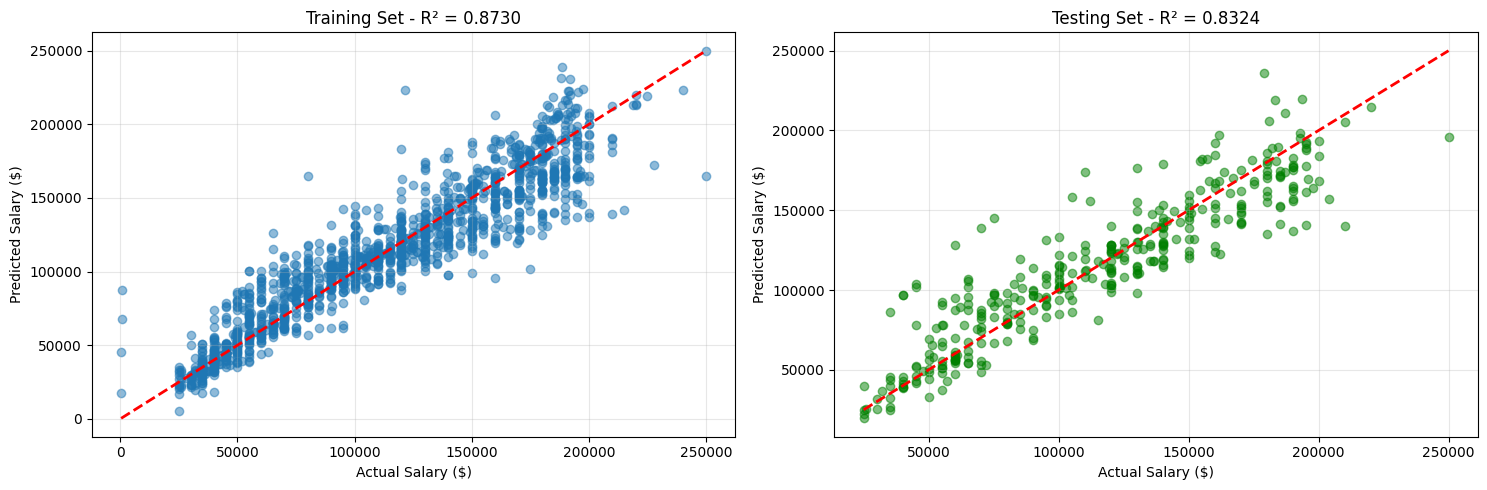

In [15]:
# Visualize Result
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Salary ($)')
axes[0].set_ylabel('Predicted Salary ($)')
axes[0].set_title(f'Training Set - R² = {train_r2:.4f}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Salary ($)')
axes[1].set_ylabel('Predicted Salary ($)')
axes[1].set_title(f'Testing Set - R² = {test_r2:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()